In [15]:
import pandas as pd

# Cargar histórico completo y parsear fecha
data = pd.read_csv('../Clean/listado_juegos.csv', parse_dates=['Fecha'])

# Ajusta esta fecha para generar gráficos de ese día
fecha_seleccionada = '2026-03-23'

# Filtrar por fecha (si no hay datos, se usa todo)
df = data[data['Fecha'] == fecha_seleccionada]
if df.empty:
    print(f"No hay datos para la fecha {fecha_seleccionada}. Mostrando todos los datos.")
    df = data
else:
    print(f"Mostrando datos para fecha: {fecha_seleccionada}")

# Previsualizar
df.head(100)

No hay datos para la fecha 2026-03-23. Mostrando todos los datos.


,Fecha,Posicion,AppID,Nombre,JugadoresConcurrentes
0,2026-03-11,1.0,730.0,Counter-Strike 2,1406656
1,2026-03-11,2.0,570.0,Dota 2,534171
2,2026-03-11,3.0,578080.0,PUBG: BATTLEGROUNDS,245530
3,2026-03-11,4.0,2868840.0,Slay the Spire 2,233140
4,2026-03-11,5.0,2676230.0,FiveM,171002
...,...,...,...,...,...
95,2026-03-11,96.0,39210.0,FINAL FANTASY XIV Online,15842
96,2026-03-11,97.0,1203620.0,Enshrouded,15453
97,2026-03-11,98.0,3472040.0,NBA 2K26,15395
98,2026-03-11,99.0,3527290.0,PEAK,15344


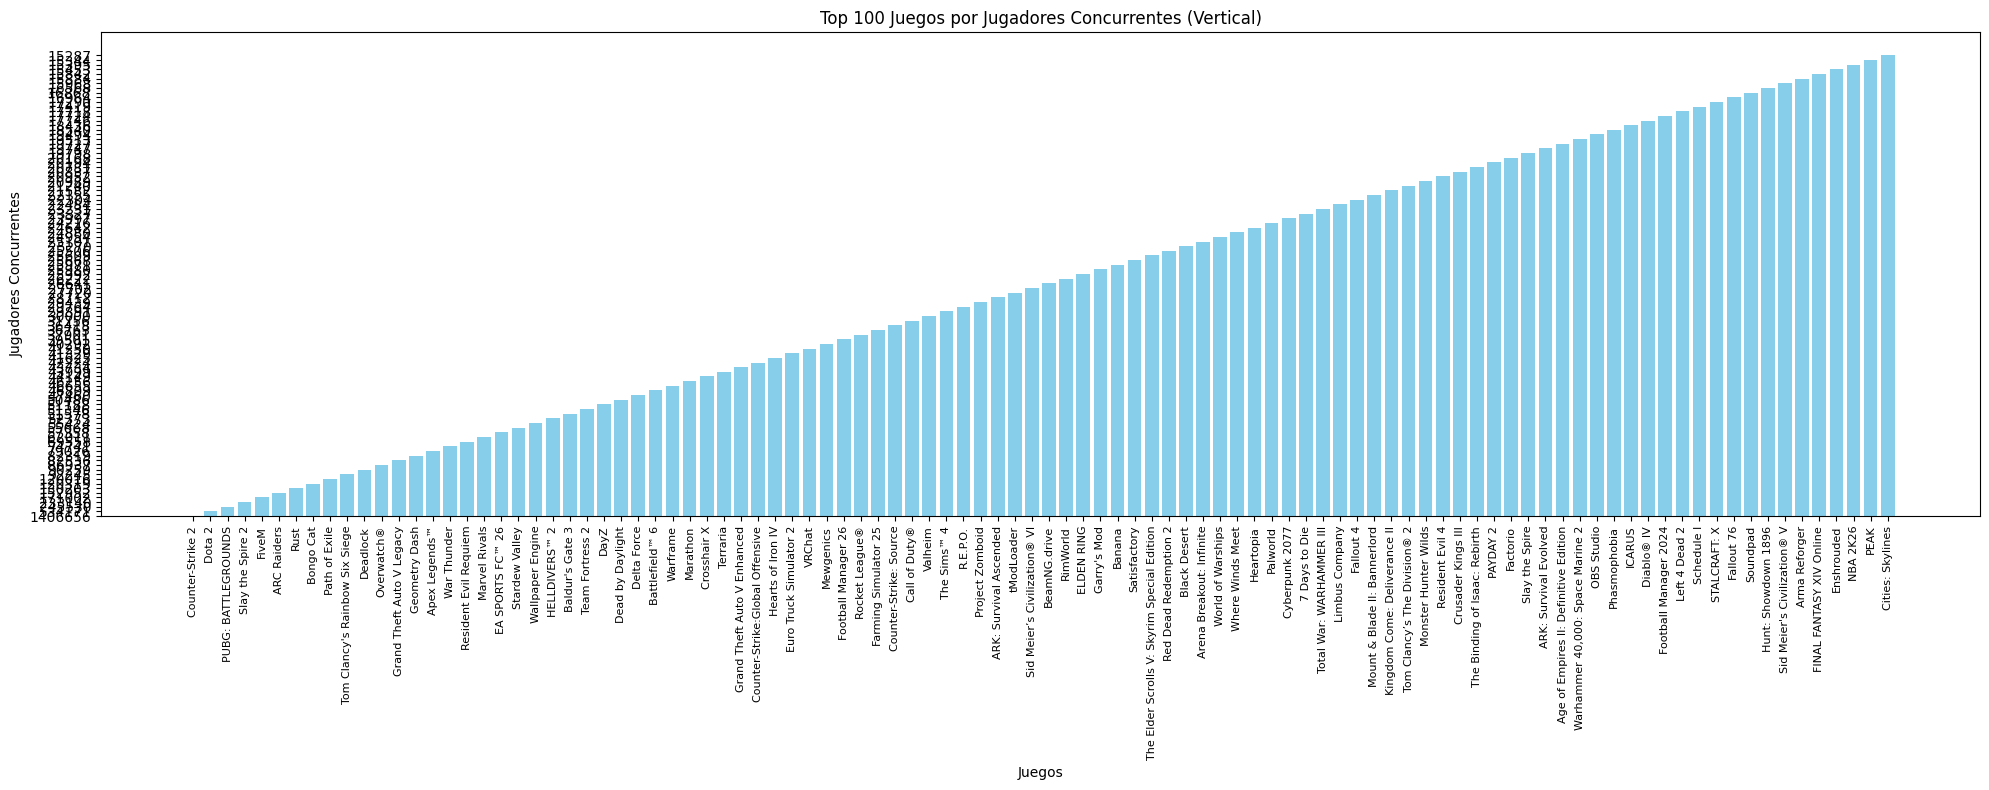

In [16]:
import matplotlib.pyplot as plt

top100_vertical = df.head(100)

plt.figure(figsize=(20,8))
plt.bar(top100_vertical["Nombre"], top100_vertical["JugadoresConcurrentes"], color='skyblue')
plt.xticks(rotation=90, ha='center', fontsize=8)
plt.xlabel('Juegos')
plt.ylabel('Jugadores Concurrentes')
plt.title('Top 100 Juegos por Jugadores Concurrentes (Vertical)')
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

# Cargar info histórica de los juegos
info = pd.read_csv('../Clean/info_juegos.csv')

# Filtrar por AppIDs del día seleccionado (si existe el conjunto)
selected_appids = set(df['AppID'].astype(str))
info_filtered = info[info['AppID'].astype(str).isin(selected_appids)]
if info_filtered.empty:
    print('No hay info específica para la fecha seleccionada. Mostrando todo.')
    info_filtered = info
else:
    print(f'Mostrando info para {len(info_filtered)} juegos de la fecha seleccionada.')

info_filtered.head(100)

No hay info específica para la fecha seleccionada. Mostrando todo.


,AppID,Nombre,Fecha_Lanzamiento,Géneros,Desarrollador
0,730,Counter-Strike 2,"21 Aug, 2012","Action, Free To Play",Valve
1,570,Dota 2,"9 Jul, 2013","Action, Strategy, Free To Play",Valve
2,578080,PUBG: BATTLEGROUNDS,"21 Dec, 2017","Action, Adventure, Massively Multiplayer, Free...",PUBG Corporation
3,2868840,Slay the Spire 2,"5 Mar, 2026","Indie, Strategy, Early Access",Mega Crit
4,2676230,FiveM,NaN,NaN,NaN
...,...,...,...,...,...
95,39210,FINAL FANTASY XIV Online,"18 Feb, 2014","Massively Multiplayer, RPG",Square Enix
96,1203620,Enshrouded,"24 Jan, 2024","Action, Adventure, Indie, RPG, Early Access",Keen Games GmbH
97,3472040,NBA 2K26,"4 Sep, 2025",Sports,Visual Concepts
98,3527290,PEAK,"16 Jun, 2025","Action, Adventure, Indie",Team PEAK


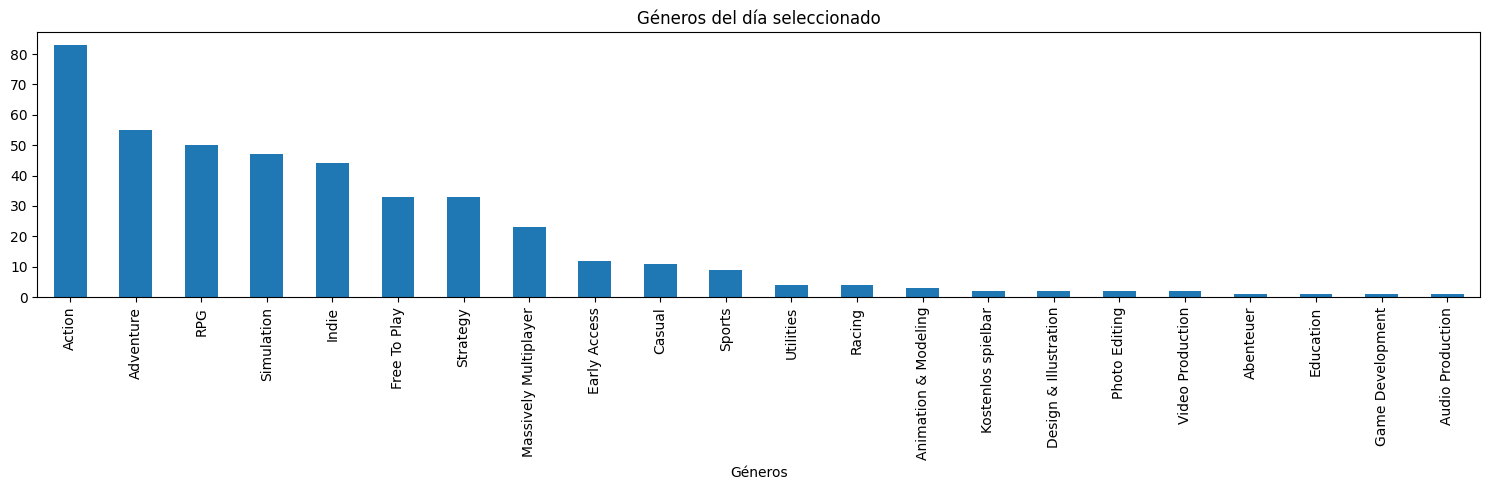

In [18]:
import matplotlib.pyplot as plt

generos = info_filtered['Géneros'].str.split(', ').explode().value_counts()

plt.figure(figsize=(15, 5))
generos.plot(kind='bar')
plt.title('Géneros del día seleccionado')
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# Reusar info filtrada
info_filtered.head(100)

,AppID,Nombre,Fecha_Lanzamiento,Géneros,Desarrollador
0,730,Counter-Strike 2,"21 Aug, 2012","Action, Free To Play",Valve
1,570,Dota 2,"9 Jul, 2013","Action, Strategy, Free To Play",Valve
2,578080,PUBG: BATTLEGROUNDS,"21 Dec, 2017","Action, Adventure, Massively Multiplayer, Free...",PUBG Corporation
3,2868840,Slay the Spire 2,"5 Mar, 2026","Indie, Strategy, Early Access",Mega Crit
4,2676230,FiveM,NaN,NaN,NaN
...,...,...,...,...,...
95,39210,FINAL FANTASY XIV Online,"18 Feb, 2014","Massively Multiplayer, RPG",Square Enix
96,1203620,Enshrouded,"24 Jan, 2024","Action, Adventure, Indie, RPG, Early Access",Keen Games GmbH
97,3472040,NBA 2K26,"4 Sep, 2025",Sports,Visual Concepts
98,3527290,PEAK,"16 Jun, 2025","Action, Adventure, Indie",Team PEAK


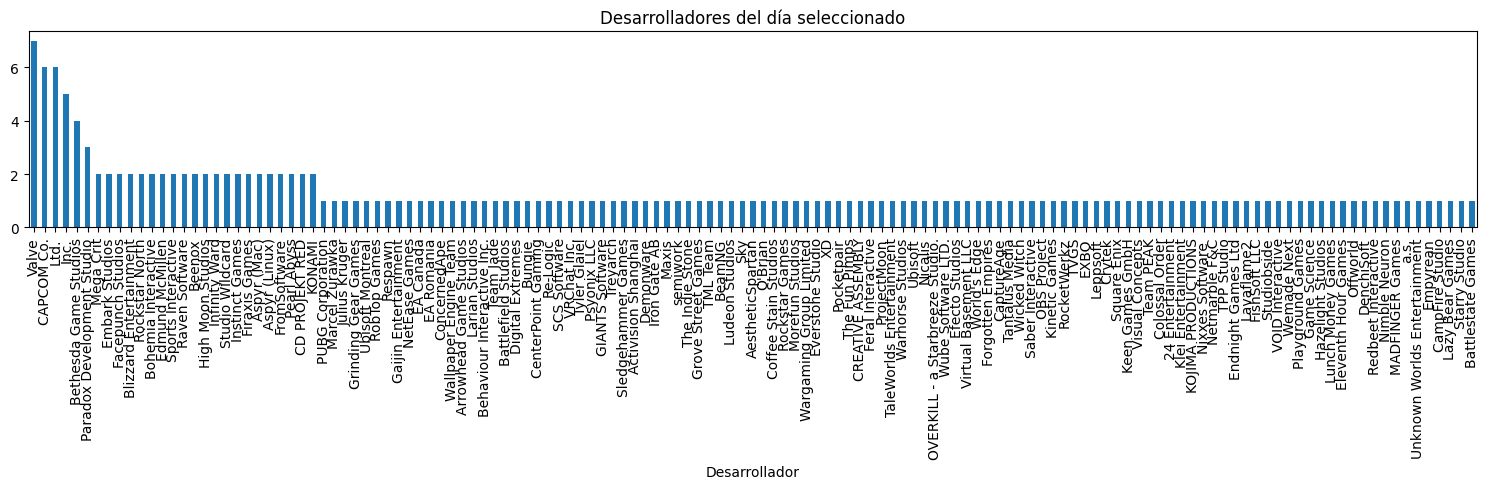

In [20]:
import matplotlib.pyplot as plt

Desarrolladores = info_filtered['Desarrollador'].str.split(', ').explode().value_counts()
plt.figure(figsize=(15, 5))
Desarrolladores.plot(kind='bar')
plt.title('Desarrolladores del día seleccionado')
plt.tight_layout()
plt.show()

Columnas: ['Nombre', 'ID']


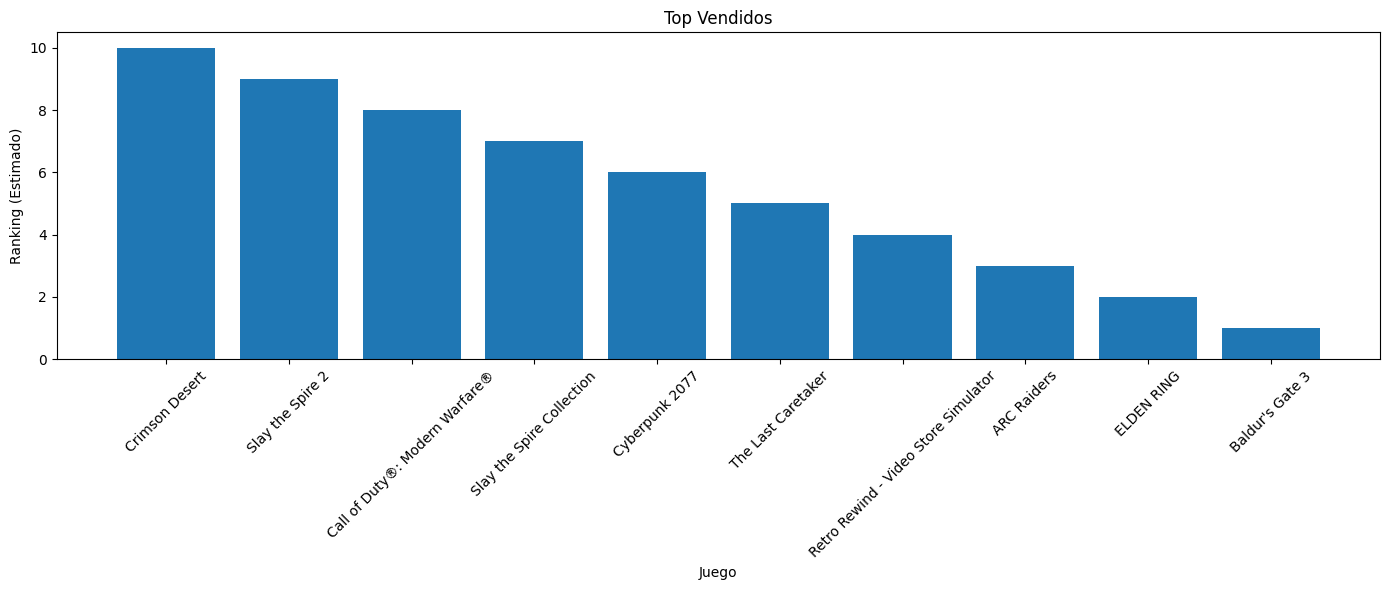

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer CSV
vendidos = pd.read_csv("../Clean/Top_vendidos.csv")

# Usar directamente los datos
vendidos_filtrados = vendidos.head(10)

print("Columnas:", vendidos_filtrados.columns.tolist())

# Elegir qué columna usar
if 'Ventas' in vendidos_filtrados.columns:
    y = vendidos_filtrados['Ventas']
    ylabel = 'Ventas'

elif 'Ranking' in vendidos_filtrados.columns:
    y = vendidos_filtrados['Ranking']
    ylabel = 'Ranking'

else:
    vendidos_filtrados = vendidos_filtrados.reset_index(drop=True)
    y = range(len(vendidos_filtrados), 0, -1)
    ylabel = 'Ranking (Estimado)'

x = vendidos_filtrados['Nombre']

# Gráfico
plt.figure(figsize=(14, 6))
plt.bar(x, y)
plt.xlabel('Juego')
plt.ylabel(ylabel)
plt.title('Top Vendidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()